## Import drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Unzip file

In [ ]:
import os
import zipfile

# For unzip and save in Google Drive
# Define file paths
zip_file_path = '/content/drive/My Drive/Turmeric_proj_2.v2i_2040_2040yolov8.zip'  # Path to your zip file on Google Drive
unzip_dir = '/content/drive/My Drive'  # Directory to unzip the file to

# Check if the unzip directory exists, if not, create it
if not os.path.exists(unzip_dir):
    os.makedirs(unzip_dir)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_dir)

print(f"Unzipped file saved to: {unzip_dir}")


Unzipped file saved to: /content/drive/My Drive


## Install require packages

In [2]:
# Install required packages
!pip install ultralytics torch torchvision --extra-index-url https://download.pytorch.org/whl/cu118
!pip install roboflow matplotlib opencv-python

import os
import cv2
import shutil
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import display, Image
import torch

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 110.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink

## Path_config & Dataset count

In [3]:
#Dataset Preparation

DATASET_PATH = "/content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8"
os.makedirs(DATASET_PATH, exist_ok=True)

# Verify dataset structure
print("Dataset structure verification:")
print(f"Train images: {len(os.listdir(os.path.join(DATASET_PATH, 'train/images')))}")
print(f"Valid images: {len(os.listdir(os.path.join(DATASET_PATH, 'valid/images')))}")
print(f"Test images: {len(os.listdir(os.path.join(DATASET_PATH, 'test/images')))}")

Dataset structure verification:
Train images: 515
Valid images: 37
Test images: 37


## Change all segmentation data to bounding box data files

### Count all segmentation,bounding box data

In [5]:
import os
from collections import defaultdict

def analyze_dataset_structure(dataset_path):
    """
    Analyzes a YOLOv8 dataset to count bounding boxes vs segmentation polygons.
    Prints detailed statistics per split (train/val/test).

    Args:
        dataset_path (str): Path to the dataset root directory
    """
    splits = ['train', 'val', 'valid', 'test']  # Common split names

    for split in splits:
        label_dir = os.path.join(dataset_path, split, 'labels')
        if not os.path.exists(label_dir):
            continue

        print(f"\n📊 Analyzing {split.upper()} set:")

        # Initialize counters
        stats = {
            'total_files': 0,
            'bbox_only': 0,
            'seg_only': 0,
            'mixed': 0,
            'total_bboxes': 0,
            'total_segs': 0,
            'class_distribution': defaultdict(int)
        }

        # Process each label file
        for label_file in os.listdir(label_dir):
            if not label_file.endswith('.txt'):
                continue

            stats['total_files'] += 1
            with open(os.path.join(label_dir, label_file), 'r') as f:
                lines = f.readlines()

            has_bbox = False
            has_seg = False

            for line in lines:
                parts = line.strip().split()
                if not parts:
                    continue

                cls_id = int(parts[0])
                stats['class_distribution'][cls_id] += 1

                if len(parts) == 5:  # Bounding box
                    stats['total_bboxes'] += 1
                    has_bbox = True
                elif len(parts) > 5:  # Segmentation
                    stats['total_segs'] += 1
                    has_seg = True

            # Count file types
            if has_bbox and has_seg:
                stats['mixed'] += 1
            elif has_bbox:
                stats['bbox_only'] += 1
            elif has_seg:
                stats['seg_only'] += 1

        # Print report
        print(f"  - Label files: {stats['total_files']}")
        print(f"  - BBox-only files: {stats['bbox_only']}")
        print(f"  - Seg-only files: {stats['seg_only']}")
        print(f"  - Mixed files: {stats['mixed']}")
        print(f"  - Total bboxes: {stats['total_bboxes']}")
        print(f"  - Total segments: {stats['total_segs']}")

        if stats['class_distribution']:
            print("  - Class distribution:")
            for cls_id, count in stats['class_distribution'].items():
                print(f"    - Class {cls_id}: {count} annotations")

# Usage (update path)
DATASET_PATH = "/content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8"
analyze_dataset_structure(DATASET_PATH)


📊 Analyzing TRAIN set:
  - Label files: 515
  - BBox-only files: 515
  - Seg-only files: 0
  - Mixed files: 0
  - Total bboxes: 5582
  - Total segments: 0
  - Class distribution:
    - Class 0: 5582 annotations

📊 Analyzing VALID set:
  - Label files: 37
  - BBox-only files: 37
  - Seg-only files: 0
  - Mixed files: 0
  - Total bboxes: 413
  - Total segments: 0
  - Class distribution:
    - Class 0: 413 annotations

📊 Analyzing TEST set:
  - Label files: 37
  - BBox-only files: 37
  - Seg-only files: 0
  - Mixed files: 0
  - Total bboxes: 449
  - Total segments: 0
  - Class distribution:
    - Class 0: 449 annotations


### Converts polygon masks → bounding boxes

In [ ]:
import os
import numpy as np
from tqdm import tqdm

def polygon2box(polygon):
    """Convert polygon points to xyxy bounding box."""
    x = polygon[::2]
    y = polygon[1::2]
    return [min(x), min(y), max(x), max(y)]

def convert_seg_to_box(label_dir):
    """Convert all segmentation labels to bounding boxes in-place."""
    for label_file in tqdm(os.listdir(label_dir), desc="Processing labels"):
        if not label_file.endswith('.txt'):
            continue

        label_path = os.path.join(label_dir, label_file)

        with open(label_path, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = list(map(float, line.strip().split()))
            if len(parts) > 5:  # Segmentation line (class_id + polygon points)
                cls_id = int(parts[0])
                polygon = parts[1:]
                x1, y1, x2, y2 = polygon2box(polygon)

                # Convert to YOLO bbox format (xywh normalized)
                img_width, img_height = 2040, 2040  # Your original image size
                x_center = ((x1 + x2) / 2) / img_width
                y_center = ((y1 + y2) / 2) / img_height
                width = (x2 - x1) / img_width
                height = (y2 - y1) / img_height

                new_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
            else:
                new_lines.append(line)  # Keep existing bbox lines

        # Overwrite the file
        with open(label_path, 'w') as f:
            f.writelines(new_lines)

def verify_fix(label_dir):
    """Check if all labels are now in bbox format."""
    for label_file in os.listdir(label_dir):
        with open(os.path.join(label_dir, label_file), 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    print(f"⚠️ Still invalid line in {label_file}: {line}")
                    return False
    print("✅ All labels converted to bbox format!")
    return True

# Paths (update these)
DATASET_PATH = "/content/drive/MyDrive/Turmeric_proj_2.v2i_2040_2040yolov8"
for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(DATASET_PATH, split, 'labels')
    if os.path.exists(label_dir):
        print(f"\nProcessing {split} set...")
        convert_seg_to_box(label_dir)
        verify_fix(label_dir)


Processing train set...


Processing labels: 100%|██████████| 515/515 [00:05<00:00, 91.58it/s] 


✅ All labels converted to bbox format!

Processing valid set...


Processing labels: 100%|██████████| 37/37 [00:00<00:00, 102.82it/s]


✅ All labels converted to bbox format!

Processing test set...


Processing labels: 100%|██████████| 37/37 [00:00<00:00, 114.37it/s]


✅ All labels converted to bbox format!


### Recheck

In [ ]:
import os
from collections import defaultdict

def analyze_dataset_structure(dataset_path):
    """
    Analyzes a YOLOv8 dataset to count bounding boxes vs segmentation polygons.
    Prints detailed statistics per split (train/val/test).

    Args:
        dataset_path (str): Path to the dataset root directory
    """
    splits = ['train', 'val', 'valid', 'test']  # Common split names

    for split in splits:
        label_dir = os.path.join(dataset_path, split, 'labels')
        if not os.path.exists(label_dir):
            continue

        print(f"\n📊 Analyzing {split.upper()} set:")

        # Initialize counters
        stats = {
            'total_files': 0,
            'bbox_only': 0,
            'seg_only': 0,
            'mixed': 0,
            'total_bboxes': 0,
            'total_segs': 0,
            'class_distribution': defaultdict(int)
        }

        # Process each label file
        for label_file in os.listdir(label_dir):
            if not label_file.endswith('.txt'):
                continue

            stats['total_files'] += 1
            with open(os.path.join(label_dir, label_file), 'r') as f:
                lines = f.readlines()

            has_bbox = False
            has_seg = False

            for line in lines:
                parts = line.strip().split()
                if not parts:
                    continue

                cls_id = int(parts[0])
                stats['class_distribution'][cls_id] += 1

                if len(parts) == 5:  # Bounding box
                    stats['total_bboxes'] += 1
                    has_bbox = True
                elif len(parts) > 5:  # Segmentation
                    stats['total_segs'] += 1
                    has_seg = True

            # Count file types
            if has_bbox and has_seg:
                stats['mixed'] += 1
            elif has_bbox:
                stats['bbox_only'] += 1
            elif has_seg:
                stats['seg_only'] += 1

        # Print report
        print(f"  - Label files: {stats['total_files']}")
        print(f"  - BBox-only files: {stats['bbox_only']}")
        print(f"  - Seg-only files: {stats['seg_only']}")
        print(f"  - Mixed files: {stats['mixed']}")
        print(f"  - Total bboxes: {stats['total_bboxes']}")
        print(f"  - Total segments: {stats['total_segs']}")

        if stats['class_distribution']:
            print("  - Class distribution:")
            for cls_id, count in stats['class_distribution'].items():
                print(f"    - Class {cls_id}: {count} annotations")

# Usage (update path)
DATASET_PATH = "/content/drive/MyDrive/Turmeric_proj_2.v2i_2040_2040yolov8"
analyze_dataset_structure(DATASET_PATH)


📊 Analyzing TRAIN set:
  - Label files: 515
  - BBox-only files: 515
  - Seg-only files: 0
  - Mixed files: 0
  - Total bboxes: 5582
  - Total segments: 0
  - Class distribution:
    - Class 0: 5582 annotations

📊 Analyzing VALID set:
  - Label files: 37
  - BBox-only files: 37
  - Seg-only files: 0
  - Mixed files: 0
  - Total bboxes: 413
  - Total segments: 0
  - Class distribution:
    - Class 0: 413 annotations

📊 Analyzing TEST set:
  - Label files: 37
  - BBox-only files: 37
  - Seg-only files: 0
  - Mixed files: 0
  - Total bboxes: 449
  - Total segments: 0
  - Class distribution:
    - Class 0: 449 annotations


# Model training

### MODEL 1
### YOLOV8n//moderate aug//data cleaned//Moderate data aug
### Initial training with low aug and non enhanced

Dataset structure verification:
Train images: 515
Valid images: 37
Test images: 37
System Configuration:
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: Tesla T4

🚀 STARTING TRAINING PROCESS
🚀 Using GPU (CUDA device 0)


100%|██████████| 6.25M/6.25M [00:00<00:00, 342MB/s]

Ultralytics 8.3.158 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Turmeric_proj_2.v2i_2040_2040yolov8/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.3, multi_scale=False, name=yolov8n_turmeric, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, per

100%|██████████| 755k/755k [00:00<00:00, 99.2MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

                   all         37        413      0.456      0.435      0.372      0.212
Speed: 6.7ms preprocess, 39.9ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to turmeric_detection/yolov8n_turmeric

VALIDATION SET EVALUATION METRICS:
• mAP50-95: 0.2116
• mAP50: 0.3723
• Inference Speed: 39.87ms/img

CLASS-WISE PERFORMANCE:
  turmeric_leaf:
    - AP50: 0.3723
    - AP50-95: 0.2116

🧪 TEST SET PERFORMANCE
Ultralytics 8.3.158 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 43.4±10.0 MB/s, size: 415.9 KB)


val: Scanning /content/drive/MyDrive/Turmeric_proj_2.v2i_2040_2040yolov8/test/labels... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<00:00, 92.82it/s]


val: New cache created: /content/drive/MyDrive/Turmeric_proj_2.v2i_2040_2040yolov8/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 218, len(boxes) = 449. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.24s/it]


                   all         37        449       0.37      0.447      0.354      0.203
Speed: 0.4ms preprocess, 21.6ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to turmeric_detection/yolov8n_turmeric

TEST SET EVALUATION METRICS:
• mAP50-95: 0.2034
• mAP50: 0.3539
• Inference Speed: 21.56ms/img

CLASS-WISE PERFORMANCE:
  turmeric_leaf:
    - AP50: 0.3539
    - AP50-95: 0.2034

💾 Saving best model...
📤 Exporting to ONNX...
Ultralytics 8.3.158 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel CPUs. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'turmeric_detection/yolov8n_turmeric/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<1.18.0', 'onnxslim>=0.1.56', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success

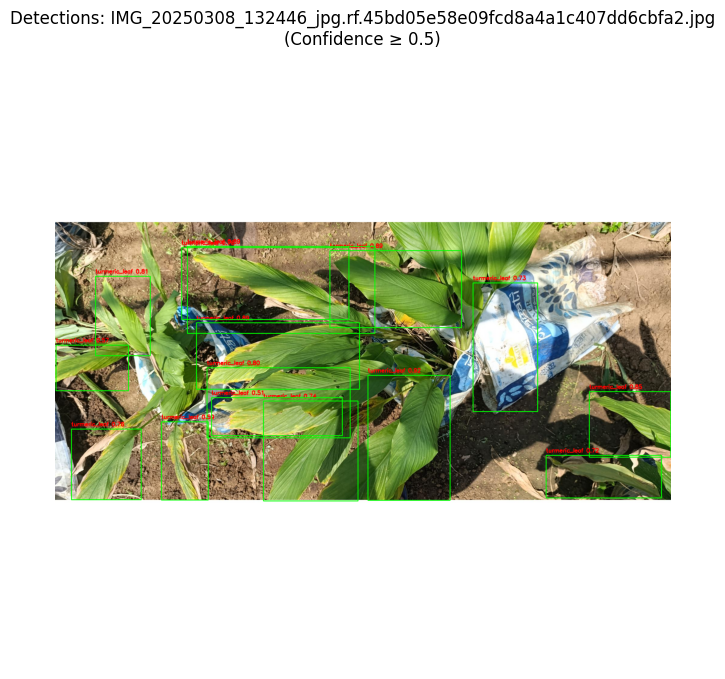


DETECTION DETAILS (IMG_20250308_132446_jpg.rf.45bd05e58e09fcd8a4a1c407dd6cbfa2.jpg):
  1. turmeric_leaf
     Confidence: 0.92
     Coordinates: [1036.7677001953125, 1067.2442626953125, 1308.6807861328125, 1481.0079345703125]
  2. turmeric_leaf
     Confidence: 0.89
     Coordinates: [468.6798095703125, 893.7379150390625, 1008.957763671875, 1113.1029052734375]
  3. turmeric_leaf
     Confidence: 0.89
     Coordinates: [910.8138427734375, 654.3869018554688, 1346.2408447265625, 909.3880615234375]
  4. turmeric_leaf
     Confidence: 0.89
     Coordinates: [438.8598327636719, 640.51416015625, 1059.1678466796875, 928.412109375]
  5. turmeric_leaf
     Confidence: 0.85
     Coordinates: [1769.592041015625, 1121.451171875, 2039.085205078125, 1338.7659912109375]
  6. turmeric_leaf
     Confidence: 0.81
     Coordinates: [134.93896484375, 739.9808349609375, 315.7004089355469, 1002.6986083984375]
  7. turmeric_leaf
     Confidence: 0.80
     Coordinates: [503.7015686035156, 1042.4456787109375, 9

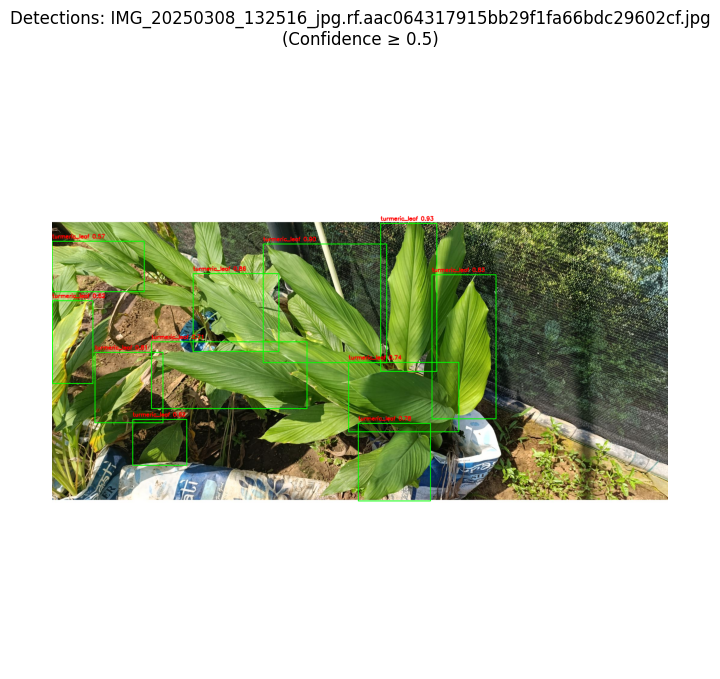


DETECTION DETAILS (IMG_20250308_132516_jpg.rf.aac064317915bb29f1fa66bdc29602cf.jpg):
  1. turmeric_leaf
     Confidence: 0.93
     Coordinates: [1088.293212890625, 564.6502075195312, 1274.453369140625, 1054.605712890625]
  2. turmeric_leaf
     Confidence: 0.90
     Coordinates: [699.69921875, 632.7387084960938, 1108.88134765625, 1025.2579345703125]
  3. turmeric_leaf
     Confidence: 0.86
     Coordinates: [467.48663330078125, 730.6758422851562, 751.690185546875, 988.2670288085938]
  4. turmeric_leaf
     Confidence: 0.83
     Coordinates: [1258.92236328125, 734.0064086914062, 1470.66796875, 1211.68359375]
  5. turmeric_leaf
     Confidence: 0.81
     Coordinates: [142.45774841308594, 991.6301879882812, 367.96588134765625, 1224.68505859375]
  6. turmeric_leaf
     Confidence: 0.78
     Coordinates: [1014.8971557617188, 1226.2265625, 1253.9017333984375, 1483.254638671875]
  7. turmeric_leaf
     Confidence: 0.74
     Coordinates: [982.7833251953125, 1024.16650390625, 1347.287719726562

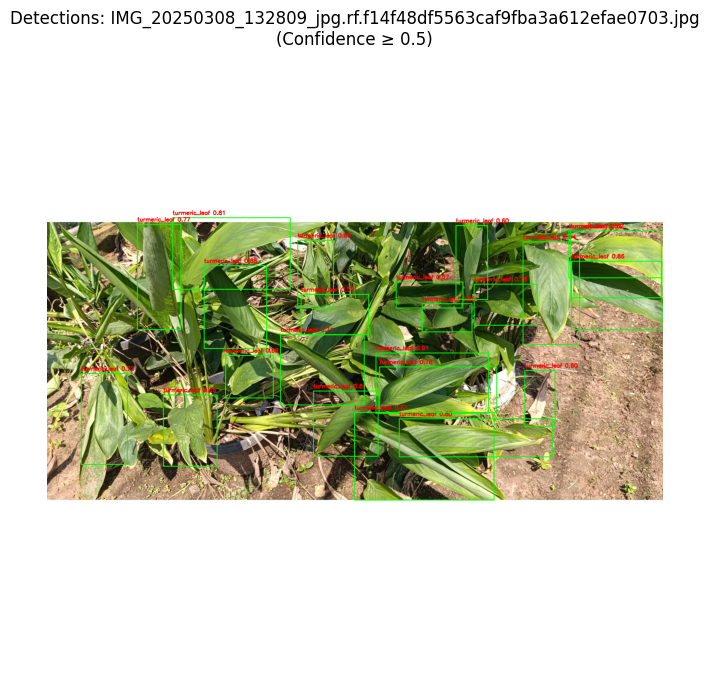


DETECTION DETAILS (IMG_20250308_132809_jpg.rf.f14f48df5563caf9fba3a612efae0703.jpg):
  1. turmeric_leaf
     Confidence: 0.94
     Coordinates: [1576.414794921875, 625.5604858398438, 1763.07470703125, 965.4004516601562]
  2. turmeric_leaf
     Confidence: 0.91
     Coordinates: [1089.0980224609375, 993.6021728515625, 1462.1202392578125, 1193.921875]
  3. turmeric_leaf
     Confidence: 0.88
     Coordinates: [520.1534423828125, 704.7321166992188, 727.459228515625, 978.6608276367188]
  4. turmeric_leaf
     Confidence: 0.86
     Coordinates: [1737.05029296875, 689.0145874023438, 2036.375732421875, 916.9957275390625]
  5. turmeric_leaf
     Confidence: 0.82
     Coordinates: [1734.467529296875, 589.3225708007812, 2034.1917724609375, 810.199951171875]
  6. turmeric_leaf
     Confidence: 0.81
     Coordinates: [882.0267944335938, 1119.7877197265625, 1096.034423828125, 1335.1658935546875]
  7. turmeric_leaf
     Confidence: 0.81
     Coordinates: [416.95574951171875, 545.0396118164062, 805.

In [ ]:

# =====================
# 1. Dataset Preparation
# =====================
DATASET_PATH = "/content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8"
os.makedirs(DATASET_PATH, exist_ok=True)

# Verify dataset structure
print("Dataset structure verification:")
print(f"Train images: {len(os.listdir(os.path.join(DATASET_PATH, 'train/images')))}")
print(f"Valid images: {len(os.listdir(os.path.join(DATASET_PATH, 'valid/images')))}")
print(f"Test images: {len(os.listdir(os.path.join(DATASET_PATH, 'test/images')))}")

# =====================
# 2. Device Configuration
# =====================
def get_device():
    if torch.cuda.is_available():
        device = "0"  # Use first GPU
        print(f" Using GPU (CUDA device 0)")
    else:
        device = "cpu"
        print(" Using CPU (CUDA not available)")
    return device

# =====================
# 3. Training Configuration
# =====================
def get_config():
    device = get_device()
    batch_size = 32 if device != "cpu" else 16

    return {
        "model": "yolov8n.pt",
        "data": os.path.join(DATASET_PATH, "data.yaml"),
        "epochs": 40 if device != "cpu" else 50,
        "imgsz": 640,
        "batch": batch_size,
        "device": device,
        "workers": 2 if device != "cpu" else 1,
        "optimizer": "AdamW",
        "lr0": 0.001,
        "lrf": 0.01,
        "weight_decay": 0.0005,
        "patience": 30,
        "augment": True,
        "hsv_h": 0.015,
        "hsv_s": 0.7,
        "hsv_v": 0.4,
        "translate": 0.1,
        "scale": 0.2,
        "fliplr": 0.5,
        "mosaic": 0.3,
        "degrees": 5.0,
        "shear": 2.0,
        "project": "turmeric_detection",
        "name": "yolov8n_turmeric",
        "exist_ok": True,
        "seed": 42
    }

# =====================
# 4. Training Function
# =====================
def train_model():
    config = get_config()
    model = YOLO(config["model"])

    try:
        results = model.train(**config)
    except RuntimeError as e:
        if "CUDA out of memory" in str(e) and config["device"] != "cpu":
            print("Reducing batch size due to GPU memory constraints...")
            config["batch"] = max(1, config["batch"] // 2)
            results = model.train(**config)
        else:
            raise e

    return model, results

# =====================
# 5. Evaluation Metrics
# =====================
def print_metrics(model, metrics, split_name):
    print(f"\n{split_name.upper()} SET EVALUATION METRICS:")
    print(f"• mAP50-95: {metrics.box.map:.4f}")
    print(f"• mAP50: {metrics.box.map50:.4f}")

    if hasattr(metrics, 'speed'):
        print(f"• Inference Speed: {metrics.speed['inference']:.2f}ms/img")

    if hasattr(metrics.box, 'ap_class_index'):
        print("\nCLASS-WISE PERFORMANCE:")
        for i, class_id in enumerate(metrics.box.ap_class_index):
            print(f"  {model.names[class_id]}:")
            print(f"    - AP50: {metrics.box.ap50[i]:.4f}")
            print(f"    - AP50-95: {metrics.box.ap[i]:.4f}")

# =====================
# 6. Enhanced Visualization (Fixed Tensor Handling)
# =====================
def visualize_detections(model, num_samples=3, conf_thresh=0.5):
    test_images = os.listdir(os.path.join(DATASET_PATH, "test/images"))[:num_samples]

    for img_name in test_images:
        img_path = os.path.join(DATASET_PATH, "test/images", img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        results = model.predict(img_path, conf=conf_thresh)

        # Draw bounding boxes
        for box in results[0].boxes:
            # Convert tensor to numpy array first
            box_coords = box.xyxy[0].cpu().numpy() if box.xyxy[0].is_cuda else box.xyxy[0].numpy()
            x1, y1, x2, y2 = map(int, box_coords)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f"{model.names[int(box.cls)]} {float(box.conf):.2f}"  # Explicit float conversion
            cv2.putText(img, label, (x1, y1-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

        # Display
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Detections: {img_name}\n(Confidence ≥ {conf_thresh})")
        plt.show()

        # Print detection details with proper tensor conversion
        print(f"\nDETECTION DETAILS ({img_name}):")
        for i, box in enumerate(results[0].boxes):
            box_coords = box.xyxy[0].cpu().numpy() if box.xyxy[0].is_cuda else box.xyxy[0].numpy()
            print(f"  {i+1}. {model.names[int(box.cls)]}")
            print(f"     Confidence: {float(box.conf):.2f}")  # Explicit float conversion
            print(f"     Coordinates: {box_coords.tolist()}")

# =====================
# 7. Main Execution Flow (Fixed ONNX Export)
# =====================
def main():
    # Check system resources
    print("="*50)
    print("System Configuration:")
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    print("="*50 + "\n")

    # Training
    print(" STARTING TRAINING PROCESS")
    model, results = train_model()

    # Evaluation
    print("\n MODEL EVALUATION")
    print("\n VALIDATION SET PERFORMANCE")
    val_metrics = model.val(split="val")
    print_metrics(model, val_metrics, "validation")

    print("\n TEST SET PERFORMANCE")
    test_metrics = model.val(split="test")
    print_metrics(model, test_metrics, "test")

    # Save and export
    print("\n Saving best model...")
    best_model_path = os.path.join(DATASET_PATH, "best_model.pt")
    model.save(best_model_path)

    print(" Exporting to ONNX...")
    onnx_path = os.path.join(DATASET_PATH, "model.onnx")

    # Export with explicit filename
    model.export(format="onnx", dynamic=True, simplify=True, imgsz=640)

    # Handle the exported file
    exported_file = os.path.join("turmeric_detection", "yolov8n_turmeric", "weights", "best.onnx")
    if os.path.exists(exported_file):
        shutil.copy(exported_file, onnx_path)
        print(f" Saved ONNX model to: {onnx_path}")
    else:
        print(f" Could not find exported ONNX file at: {exported_file}")
        # Try alternative path
        exported_file_alt = os.path.join("turmeric_detection", "yolov8n_turmeric", "weights", "best.pt.onnx")
        if os.path.exists(exported_file_alt):
            shutil.copy(exported_file_alt, onnx_path)
            print(f" Saved ONNX model (alternate path) to: {onnx_path}")

    # Visualization
    print("\n PREDICTION VISUALIZATIONS")
    visualize_detections(model, num_samples=3, conf_thresh=0.5)

    # Save training plots
    print("\n Saving training plots...")
    plots_dir = os.path.join(DATASET_PATH, "training_plots")
    os.makedirs(plots_dir, exist_ok=True)

    training_artifacts = os.path.join("turmeric_detection", "yolov8n_turmeric")
    for plot in ['results.png', 'confusion_matrix.png', 'F1_curve.png']:
        src = os.path.join(training_artifacts, plot)
        if os.path.exists(src):
            shutil.copy(src, plots_dir)

    print("\n TRAINING COMPLETE!")
    print(f"All outputs saved to: {DATASET_PATH}")
    print("="*50)
    print("Output Files:")
    print(f"- best_model.pt (best weights)")
    print(f"- model.onnx (exported model)")
    print(f"- training_plots/ (training metrics)")
    print("="*50)

if __name__ == "__main__":
    main()

### MODEL 2
### YOLOV8n//HIGH AUG//data cleaned//Moderate data aug
### Enhanced model

### Enhanced model

### Evaluating model

In [ ]:
import os
import shutil
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np
from datetime import datetime
from pathlib import Path
import time
from thop import profile  # For FLOPs calculation

# =====================
# 1. Configuration
# =====================
DATASET_PATH = "/content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8"
MODEL_VERSION = "enhanced_01_n"  # Version suffix for saving
SAVE_DIR = os.path.join(DATASET_PATH, f"results_{MODEL_VERSION}")
os.makedirs(SAVE_DIR, exist_ok=True)

# =====================
# 2. Dataset Verification
# =====================
def verify_dataset():
    print("\n Dataset Structure Verification:")
    dataset_stats = {}
    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(DATASET_PATH, split, 'images')
        lbl_dir = os.path.join(DATASET_PATH, split, 'labels')

        if os.path.exists(img_dir):
            num_images = len(os.listdir(img_dir))
            num_labels = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
            dataset_stats[split] = (num_images, num_labels)
            print(f"{split.upper():<6}: {num_images} images | {num_labels} labels")

    # Save dataset stats
    with open(os.path.join(SAVE_DIR, 'dataset_stats.txt'), 'w') as f:
        for split, (img, lbl) in dataset_stats.items():
            f.write(f"{split}: {img} images, {lbl} labels\n")

    return dataset_stats

# =====================
# 3. Enhanced Training Config
# =====================
def get_config():
    return {
        "model": "yolov8n.pt",
        "data": os.path.join(DATASET_PATH, "data.yaml"),
        "epochs": 100,
        "imgsz": 640,
        "batch": 32 if torch.cuda.is_available() else 8,
        "device": "0" if torch.cuda.is_available() else "cpu",
        "workers": 4,
        "optimizer": "AdamW",
        "lr0": 0.01,
        "lrf": 0.1,
        "cos_lr": True,
        "weight_decay": 0.0005,
        "warmup_epochs": 5,
        "warmup_momentum": 0.8,
        "warmup_bias_lr": 0.1,
        "box": 7.5,
        "cls": 1.0,
        "dfl": 1.5,
        "augment": True,
        "hsv_h": 0.02,
        "hsv_s": 0.8,
        "hsv_v": 0.5,
        "translate": 0.2,
        "scale": 0.3,
        "fliplr": 0.5,
        "mosaic": 1.0,
        "mixup": 0.2,
        "degrees": 15.0,
        "shear": 5.0,
        "patience": 50,
        "project": "turmeric_detection_v2",
        "name": f"yolov8n_turmeric_{MODEL_VERSION}",
        "exist_ok": True,
        "seed": 42,
        "save_period": 10,
        "val": True
    }

# =====================
# 4. Enhanced Training Function
# =====================
def train_model():
    config = get_config()
    print("\n Training Configuration:")
    for k, v in config.items():
        print(f"{k:>20}: {v}")

    # Save config
    with open(os.path.join(SAVE_DIR, 'train_config.txt'), 'w') as f:
        for k, v in config.items():
            f.write(f"{k}: {v}\n")

    model = YOLO(config["model"])

    try:
        results = model.train(**config)
    except RuntimeError as e:
        if "CUDA out of memory" in str(e):
            print(" Reducing batch size due to GPU memory constraints...")
            config["batch"] = max(8, config["batch"] // 2)
            results = model.train(**config)
        else:
            raise e

    return model, results

# =====================
# 5. Enhanced Visualization
# =====================
def visualize_predictions(model, conf_thresh=0.5):
    test_dir = os.path.join(DATASET_PATH, "test/images")
    vis_dir = os.path.join(SAVE_DIR, "visualizations")
    os.makedirs(vis_dir, exist_ok=True)

    print("\n Generating prediction visualizations...")
    for img_name in os.listdir(test_dir)[:5]:  # First 5 samples
        img_path = os.path.join(test_dir, img_name)
        results = model.predict(img_path, conf=conf_thresh, augment=True)

        # Create figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        fig.suptitle(f"Turmeric Leaf Detection - {MODEL_VERSION}", fontsize=16)

        # Original image
        orig_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        ax1.imshow(orig_img)
        ax1.set_title("Original Image", fontsize=12)
        ax1.axis('off')

        # Predictions
        res_img = results[0].plot()
        ax2.imshow(res_img)
        ax2.set_title(f"Predictions (conf ≥ {conf_thresh})", fontsize=12)
        ax2.axis('off')

        # Save visualization
        vis_path = os.path.join(vis_dir, f"pred_{os.path.splitext(img_name)[0]}.png")
        plt.savefig(vis_path, bbox_inches='tight', dpi=150)
        plt.close()

    print(f" Visualizations saved to: {vis_dir}")

# =====================
# 6. Performance Analysis
# =====================
def analyze_performance(model):
    print("\n Performance Analysis")

    # Validate on test set
    metrics = model.val(split='test')

    # Save metrics
    metrics_path = os.path.join(SAVE_DIR, 'performance_metrics.txt')
    with open(metrics_path, 'w') as f:
        f.write(f"Model Version: {MODEL_VERSION}\n")
        f.write(f"Evaluation Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        f.write("Test Set Metrics:\n")
        f.write(f"mAP50: {metrics.box.map50:.4f}\n")
        f.write(f"mAP50-95: {metrics.box.map:.4f}\n")

        # Handle precision and recall
        if hasattr(metrics.box, 'p'):
            if isinstance(metrics.box.p, (float, int)):
                f.write(f"Precision: {metrics.box.p:.4f}\n")
            elif hasattr(metrics.box.p, '__len__'):
                f.write(f"Precision (mean): {np.mean(metrics.box.p):.4f}\n")

        if hasattr(metrics.box, 'r'):
            if isinstance(metrics.box.r, (float, int)):
                f.write(f"Recall: {metrics.box.r:.4f}\n")
            elif hasattr(metrics.box.r, '__len__'):
                f.write(f"Recall (mean): {np.mean(metrics.box.r):.4f}\n")

        f.write(f"Inference Speed: {metrics.speed['inference']:.2f} ms/img\n")

        # Class-wise metrics if available
        if hasattr(metrics.box, 'ap_class_index'):
            f.write("\nClass-wise Performance:\n")
            for i, class_id in enumerate(metrics.box.ap_class_index):
                class_name = model.names[class_id]
                f.write(f"{class_name}:\n")
                if hasattr(metrics.box, 'p') and len(metrics.box.p) > i:
                    f.write(f"  Precision: {metrics.box.p[i]:.4f}\n")
                if hasattr(metrics.box, 'r') and len(metrics.box.r) > i:
                    f.write(f"  Recall: {metrics.box.r[i]:.4f}\n")
                f.write(f"  AP50: {metrics.box.ap50[i]:.4f}\n")
                f.write(f"  AP50-95: {metrics.box.ap[i]:.4f}\n")

    print(f" Performance metrics saved to: {metrics_path}")
    return metrics

# =====================
# 7. Model Saving
# =====================
def save_model(model):
    print("\n Saving model artifacts...")

    # Save PyTorch model
    pt_path = os.path.join(SAVE_DIR, f"best_{MODEL_VERSION}.pt")
    model.save(pt_path)

    # Export to ONNX
    onnx_path = os.path.join(SAVE_DIR, f"model_{MODEL_VERSION}.onnx")
    success = model.export(format="onnx", dynamic=True, simplify=True, imgsz=640)

    if success:
        # Find and move the exported model
        export_dir = os.path.join(model.trainer.save_dir, 'weights')
        for file in os.listdir(export_dir):
            if file.endswith('.onnx'):
                shutil.move(os.path.join(export_dir, file), onnx_path)
                print(f" ONNX model saved to: {onnx_path}")
                break

    # Save training plots
    plots = ['results.png', 'confusion_matrix.png', 'F1_curve.png']
    for plot in plots:
        src = os.path.join(model.trainer.save_dir, plot)
        if os.path.exists(src):
            dest = os.path.join(SAVE_DIR, f"{plot.split('.')[0]}_{MODEL_VERSION}.png")
            shutil.copy(src, dest)
            print(f" Training plot saved: {dest}")

    return pt_path, onnx_path

# =====================
# 8. Model Evaluation for Jetson Compatibility
# =====================
def evaluate_model(model_path, test_images_dir, data_yaml):
    
    # Load model
    model = YOLO(model_path)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    print(f"\n🔍 Evaluating Model: {os.path.basename(model_path)}")
    print("=" * 60)

    # 1. Model Architecture Metrics
    print("\n📐 Model Architecture:")

    # Get model size
    model_size = os.path.getsize(model_path)/1e6  # in MB
    print(f"- Model size: {model_size:.2f}MB")

    # Try to get model info - handle cases where it might return None
    try:
        model_info = model.info(verbose=False)

        if model_info is None:
            print("- Parameters: Could not retrieve parameter count")
            print("- FLOPs: Could not retrieve FLOP count")
        elif isinstance(model_info, tuple):
            # New format: (parameters, gradients, flops)
            params, _, flops = model_info
            print(f"- Parameters: {params/1e6:.2f}M")
            print(f"- FLOPs: {flops/1e9:.2f}B")
        elif isinstance(model_info, dict):
            # Old format: dictionary
            print(f"- Parameters: {model_info.get('parameters', 'N/A')}")
            print(f"- FLOPs: {model_info.get('flops', 'N/A')}")
        else:
            print("- Parameters: Unknown format returned by model.info()")
    except Exception as e:
        print(f"- Could not retrieve model info: {str(e)}")

    # 2. Speed Benchmark
    print("\n Speed Performance:")
    img_files = list(Path(test_images_dir).glob("*.*"))[:10]  # Test on first 10 images
    if not img_files:
        raise FileNotFoundError(f"No images found in {test_images_dir}")

    # Warmup
    dummy_img = cv2.imread(str(img_files[0]))
    for _ in range(10):
        _ = model.predict(dummy_img, verbose=False)

    # Benchmark
    latencies = []
    for img_file in img_files:
        img = cv2.imread(str(img_file))
        start = time.time()
        _ = model.predict(img, verbose=False, device=device)
        latencies.append(time.time() - start)

    avg_latency = np.mean(latencies) * 1000  # ms
    fps = 1000 / avg_latency
    print(f"- Average latency: {avg_latency:.2f}ms")
    print(f"- Estimated FPS: {fps:.1f}")
    if torch.cuda.is_available():
        print(f"- Device: {torch.cuda.get_device_name(0)}")

    # 3. Accuracy Metrics
    print("\n Accuracy Metrics:")
    try:
        metrics = model.val(data=data_yaml, split='test')
        print(f"- mAP50: {metrics.box.map50:.4f}")
        print(f"- mAP50-95: {metrics.box.map:.4f}")

        if hasattr(metrics.box, 'p'):
            precision = np.mean(metrics.box.p) if isinstance(metrics.box.p, np.ndarray) else metrics.box.p
            print(f"- Precision: {precision:.4f}")
        if hasattr(metrics.box, 'r'):
            recall = np.mean(metrics.box.r) if isinstance(metrics.box.r, np.ndarray) else metrics.box.r
            print(f"- Recall: {recall:.4f}")
    except Exception as e:
        print(f"- Could not compute accuracy metrics: {str(e)}")

    # 4. Computational Complexity
    print("\n Computational Load:")
    try:
        dummy_input = torch.randn(1, 3, 640, 640).to(device)
        macs, params = profile(model.model, inputs=(dummy_input,), verbose=False)
        print(f"- FLOPs: {macs/1e9:.2f}B")
        print(f"- MACs: {macs/1e6:.2f}M")
    except Exception as e:
        print(f"- FLOPs calculation failed: {str(e)}")
        macs = None

    # 5. Memory Footprint
    print("\n Memory Estimates:")
    if torch.cuda.is_available():
        mem_used = torch.cuda.max_memory_allocated() / 1e6
        print(f"- Max GPU memory used: {mem_used:.2f}MB")

    print("\n" + "=" * 60)
    print(" Jetson Nano Suitability Assessment:")
    print(f"Model Size: {' Good (<15MB)' if model_size < 15 else ' Large (>15MB)'}")

    if 'metrics' in locals():
        print(f"mAP50: {' Good (>0.35)' if metrics.box.map50 > 0.35 else ' Low (<0.35)'}")
    else:
        print("mAP50: Could not assess")

    print(f"PC FPS: {' Fast (>80)' if fps > 80 else ' Slow (<80)'}")

    if macs is not None:
        print(f"FLOPs: {' Efficient (<10B)' if macs/1e9 < 10 else ' Heavy (>10B)'}")
    elif 'flops' in locals():
        print(f"FLOPs: {' Efficient (<10B)' if flops/1e9 < 10 else ' Heavy (>10B)'}")
    else:
        print("FLOPs: Could not assess")

# =====================
# 9. Main Execution
# =====================
if __name__ == "__main__":
    print(f"\n Starting YOLOv8 Training - Version: {MODEL_VERSION}")
    print("="*60)

    # Verify dataset
    dataset_stats = verify_dataset()

    # Training
    print("\n Beginning Model Training")
    model, results = train_model()

    # Performance analysis
    metrics = analyze_performance(model)

    # Visualization
    visualize_predictions(model, conf_thresh=0.5)

    # Model saving
    pt_path, onnx_path = save_model(model)

    # Model evaluation for Jetson compatibility
    print("\n🔬 Running Jetson Compatibility Evaluation")
    test_images_dir = os.path.join(DATASET_PATH, "test/images")
    data_yaml = os.path.join(DATASET_PATH, "data.yaml")
    evaluate_model(pt_path, test_images_dir, data_yaml)

    print("\n Training Complete!")
    print("="*60)
    print(f"Model Version: {MODEL_VERSION}")
    if 'metrics' in locals():
        print(f"Best mAP50: {metrics.box.map50:.4f}")
        print(f"Best mAP50-95: {metrics.box.map:.4f}")
    print(f"\nSaved Artifacts:")
    print(f"- PyTorch model: {pt_path}")
    print(f"- ONNX model: {onnx_path}")
    print(f"- Visualizations: {os.path.join(SAVE_DIR, 'visualizations')}")
    print(f"- Performance metrics: {os.path.join(SAVE_DIR, 'performance_metrics.txt')}")
    print("="*60)


🚀 Starting YOLOv8 Training - Version: enhanced_01_n

🔍 Dataset Structure Verification:
TRAIN : 515 images | 515 labels
VALID : 37 images | 37 labels
TEST  : 37 images | 37 labels

🔥 Beginning Model Training

⚙️ Training Configuration:
               model: yolov8n.pt
                data: /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/data.yaml
              epochs: 100
               imgsz: 640
               batch: 32
              device: 0
             workers: 4
           optimizer: AdamW
                 lr0: 0.01
                 lrf: 0.1
              cos_lr: True
        weight_decay: 0.0005
       warmup_epochs: 5
     warmup_momentum: 0.8
      warmup_bias_lr: 0.1
                 box: 7.5
                 cls: 1.0
                 dfl: 1.5
             augment: True
               hsv_h: 0.02
               hsv_s: 0.8
               hsv_v: 0.5
           translate: 0.2
               scale: 0.3
              fliplr: 0.5
      

train: Scanning /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/train/labels.cache... 515 images, 0 backgrounds, 0 corrupt: 100%|██████████| 515/515 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


WARNING ⚠️ val: Slow image access detected (ping: 40.9±84.9 ms, read: 68.1±58.8 MB/s, size: 431.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/


val: Scanning /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/valid/labels.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]


...

                   all         37        413       0.66      0.598      0.632      0.378
Speed: 0.3ms preprocess, 8.4ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to turmeric_detection_v2/yolov8n_turmeric_enhanced_01_n

📈 Performance Analysis
Ultralytics 8.3.158 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.2±1.6 ms, read: 156.5±29.2 MB/s, size: 444.1 KB)


val: Scanning /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/test/labels.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.14s/it]


                   all         37        449      0.672      0.626      0.664      0.392
Speed: 13.2ms preprocess, 10.5ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to turmeric_detection_v2/yolov8n_turmeric_enhanced_01_n
✅ Performance metrics saved to: /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/results_enhanced_01_n/performance_metrics.txt

📊 Generating prediction visualizations...

image 1/1 /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/test/images/IMG_20250308_132446_jpg.rf.45bd05e58e09fcd8a4a1c407dd6cbfa2.jpg: 640x640 12 turmeric_leafs, 26.1ms
Speed: 5.7ms preprocess, 26.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/test/images/IMG_20250308_132516_jpg.rf.aac064317915bb29f1fa66bdc29602cf.jpg: 640x640 7 turmeric_leafs, 22.7ms
Speed: 3.6ms prep

val: Scanning /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/test/labels.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:02<00:00,  1.11it/s]


                   all         37        449      0.693      0.622      0.671      0.394
Speed: 7.2ms preprocess, 11.8ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to runs/detect/val2
- mAP50: 0.6708
- mAP50-95: 0.3937
- Precision: 0.6925
- Recall: 0.6221

🧮 Computational Load:
- FLOPs: 4.04B
- MACs: 4042.60M

💾 Memory Estimates:
- Max GPU memory used: 8063.81MB

📊 Jetson Nano Suitability Assessment:
Model Size: ✅ Good (<15MB)
mAP50: ✅ Good (>0.35)
PC FPS: ✅ Fast (>80)
FLOPs: ✅ Efficient (<10B)

🎉 Training Complete!
Model Version: enhanced_01_n
Best mAP50: 0.6640
Best mAP50-95: 0.3916

Saved Artifacts:
- PyTorch model: /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/results_enhanced_01_n/best_enhanced_01_n.pt
- ONNX model: /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/results_enhanced_01_n/model_enhanced_01_n.onnx
- Visualizations: /content/drive/MyDrive/Turmeric_proj_2.v2i

In [ ]:
import os
import shutil
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np
from datetime import datetime
from pathlib import Path
import time
from thop import profile  # For FLOPs calculation

# =====================
# 1. Configuration
# =====================
DATASET_PATH = "/content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8"
MODEL_VERSION = "enhanced_yolov8s"  # Changed to yolov8s suffix
SAVE_DIR = os.path.join(DATASET_PATH, f"results_{MODEL_VERSION}")
os.makedirs(SAVE_DIR, exist_ok=True)

# =====================
# 2. Dataset Verification
# =====================
def verify_dataset():
    print("\n Dataset Structure Verification:")
    dataset_stats = {}
    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(DATASET_PATH, split, 'images')
        lbl_dir = os.path.join(DATASET_PATH, split, 'labels')

        if os.path.exists(img_dir):
            num_images = len(os.listdir(img_dir))
            num_labels = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
            dataset_stats[split] = (num_images, num_labels)
            print(f"{split.upper():<6}: {num_images} images | {num_labels} labels")

    # Save dataset stats
    with open(os.path.join(SAVE_DIR, 'dataset_stats.txt'), 'w') as f:
        for split, (img, lbl) in dataset_stats.items():
            f.write(f"{split}: {img} images, {lbl} labels\n")

    return dataset_stats

# =====================
# 3. Enhanced Training Config for YOLOv8s
# =====================
def get_config():
    return {
        "model": "yolov8s.pt",  # Changed to yolov8s model
        "data": os.path.join(DATASET_PATH, "data.yaml"),
        "epochs": 100,
        "imgsz": 640,
        "batch": 24 if torch.cuda.is_available() else 8,  # Reduced batch size for yolov8s
        "device": "0" if torch.cuda.is_available() else "cpu",
        "workers": 4,
        "optimizer": "AdamW",
        "lr0": 0.01,
        "lrf": 0.1,
        "cos_lr": True,
        "weight_decay": 0.0005,
        "warmup_epochs": 5,
        "warmup_momentum": 0.8,
        "warmup_bias_lr": 0.1,
        "box": 7.5,
        "cls": 1.0,
        "dfl": 1.5,
        "augment": True,
        "hsv_h": 0.02,
        "hsv_s": 0.8,
        "hsv_v": 0.5,
        "translate": 0.2,
        "scale": 0.3,
        "fliplr": 0.5,
        "mosaic": 1.0,
        "mixup": 0.2,
        "degrees": 15.0,
        "shear": 5.0,
        "patience": 50,
        "project": "turmeric_detection_v2",
        "name": f"yolov8s_turmeric_{MODEL_VERSION}",  # Changed to yolov8s
        "exist_ok": True,
        "seed": 42,
        "save_period": 10,
        "val": True
    }

# =====================
# 4. Enhanced Training Function
# =====================
def train_model():
    config = get_config()
    print("\n Training Configuration:")
    for k, v in config.items():
        print(f"{k:>20}: {v}")

    # Save config
    with open(os.path.join(SAVE_DIR, 'train_config.txt'), 'w') as f:
        for k, v in config.items():
            f.write(f"{k}: {v}\n")

    model = YOLO(config["model"])

    try:
        results = model.train(**config)
    except RuntimeError as e:
        if "CUDA out of memory" in str(e):
            print(" Reducing batch size due to GPU memory constraints...")
            config["batch"] = max(8, config["batch"] // 2)
            results = model.train(**config)
        else:
            raise e

    return model, results

# =====================
# 5. Enhanced Visualization
# =====================
def visualize_predictions(model, conf_thresh=0.5):
    test_dir = os.path.join(DATASET_PATH, "test/images")
    vis_dir = os.path.join(SAVE_DIR, "visualizations")
    os.makedirs(vis_dir, exist_ok=True)

    print("\n Generating prediction visualizations...")
    for img_name in os.listdir(test_dir)[:5]:  # First 5 samples
        img_path = os.path.join(test_dir, img_name)
        results = model.predict(img_path, conf=conf_thresh, augment=True)

        # Create figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        fig.suptitle(f"Turmeric Leaf Detection - {MODEL_VERSION}", fontsize=16)

        # Original image
        orig_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        ax1.imshow(orig_img)
        ax1.set_title("Original Image", fontsize=12)
        ax1.axis('off')

        # Predictions
        res_img = results[0].plot()
        ax2.imshow(res_img)
        ax2.set_title(f"Predictions (conf ≥ {conf_thresh})", fontsize=12)
        ax2.axis('off')

        # Save visualization
        vis_path = os.path.join(vis_dir, f"pred_{os.path.splitext(img_name)[0]}.png")
        plt.savefig(vis_path, bbox_inches='tight', dpi=150)
        plt.close()

    print(f" Visualizations saved to: {vis_dir}")

# =====================
# 6. Performance Analysis
# =====================
def analyze_performance(model):
    print("\n Performance Analysis")

    # Validate on test set
    metrics = model.val(split='test')

    # Save metrics
    metrics_path = os.path.join(SAVE_DIR, 'performance_metrics.txt')
    with open(metrics_path, 'w') as f:
        f.write(f"Model Version: {MODEL_VERSION}\n")
        f.write(f"Evaluation Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        f.write("Test Set Metrics:\n")
        f.write(f"mAP50: {metrics.box.map50:.4f}\n")
        f.write(f"mAP50-95: {metrics.box.map:.4f}\n")

        # Handle precision and recall
        if hasattr(metrics.box, 'p'):
            if isinstance(metrics.box.p, (float, int)):
                f.write(f"Precision: {metrics.box.p:.4f}\n")
            elif hasattr(metrics.box.p, '__len__'):
                f.write(f"Precision (mean): {np.mean(metrics.box.p):.4f}\n")

        if hasattr(metrics.box, 'r'):
            if isinstance(metrics.box.r, (float, int)):
                f.write(f"Recall: {metrics.box.r:.4f}\n")
            elif hasattr(metrics.box.r, '__len__'):
                f.write(f"Recall (mean): {np.mean(metrics.box.r):.4f}\n")

        f.write(f"Inference Speed: {metrics.speed['inference']:.2f} ms/img\n")

        # Class-wise metrics if available
        if hasattr(metrics.box, 'ap_class_index'):
            f.write("\nClass-wise Performance:\n")
            for i, class_id in enumerate(metrics.box.ap_class_index):
                class_name = model.names[class_id]
                f.write(f"{class_name}:\n")
                if hasattr(metrics.box, 'p') and len(metrics.box.p) > i:
                    f.write(f"  Precision: {metrics.box.p[i]:.4f}\n")
                if hasattr(metrics.box, 'r') and len(metrics.box.r) > i:
                    f.write(f"  Recall: {metrics.box.r[i]:.4f}\n")
                f.write(f"  AP50: {metrics.box.ap50[i]:.4f}\n")
                f.write(f"  AP50-95: {metrics.box.ap[i]:.4f}\n")

    print(f" Performance metrics saved to: {metrics_path}")
    return metrics

# =====================
# 7. Model Saving
# =====================
def save_model(model):
    print("\n💾 Saving model artifacts...")

    # Save PyTorch model
    pt_path = os.path.join(SAVE_DIR, f"best_{MODEL_VERSION}.pt")
    model.save(pt_path)

    # Export to ONNX
    onnx_path = os.path.join(SAVE_DIR, f"model_{MODEL_VERSION}.onnx")
    success = model.export(format="onnx", dynamic=True, simplify=True, imgsz=640)

    if success:
        # Find and move the exported model
        export_dir = os.path.join(model.trainer.save_dir, 'weights')
        for file in os.listdir(export_dir):
            if file.endswith('.onnx'):
                shutil.move(os.path.join(export_dir, file), onnx_path)
                print(f" ONNX model saved to: {onnx_path}")
                break

    # Save training plots
    plots = ['results.png', 'confusion_matrix.png', 'F1_curve.png']
    for plot in plots:
        src = os.path.join(model.trainer.save_dir, plot)
        if os.path.exists(src):
            dest = os.path.join(SAVE_DIR, f"{plot.split('.')[0]}_{MODEL_VERSION}.png")
            shutil.copy(src, dest)
            print(f" Training plot saved: {dest}")

    return pt_path, onnx_path

# =====================
# 8. Model Evaluation for Jetson Compatibility
# =====================
def evaluate_model(model_path, test_images_dir, data_yaml):
    """
    Evaluate a trained YOLO model and extract Jetson-relevant metrics

    Args:
        model_path: Path to .pt model file
        test_images_dir: Directory containing test images
        data_yaml: Path to data.yaml used for training
    """
    # Load model
    model = YOLO(model_path)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    print(f"\n Evaluating Model: {os.path.basename(model_path)}")
    print("=" * 60)

    # 1. Model Architecture Metrics
    print("\n Model Architecture:")

    # Get model size
    model_size = os.path.getsize(model_path)/1e6  # in MB
    print(f"- Model size: {model_size:.2f}MB")

    # Try to get model info - handle cases where it might return None
    try:
        model_info = model.info(verbose=False)

        if model_info is None:
            print("- Parameters: Could not retrieve parameter count")
            print("- FLOPs: Could not retrieve FLOP count")
        elif isinstance(model_info, tuple):
            # New format: (parameters, gradients, flops)
            params, _, flops = model_info
            print(f"- Parameters: {params/1e6:.2f}M")
            print(f"- FLOPs: {flops/1e9:.2f}B")
        elif isinstance(model_info, dict):
            # Old format: dictionary
            print(f"- Parameters: {model_info.get('parameters', 'N/A')}")
            print(f"- FLOPs: {model_info.get('flops', 'N/A')}")
        else:
            print("- Parameters: Unknown format returned by model.info()")
    except Exception as e:
        print(f"- Could not retrieve model info: {str(e)}")

    # 2. Speed Benchmark
    print("\n Speed Performance:")
    img_files = list(Path(test_images_dir).glob("*.*"))[:10]  # Test on first 10 images
    if not img_files:
        raise FileNotFoundError(f"No images found in {test_images_dir}")

    # Warmup
    dummy_img = cv2.imread(str(img_files[0]))
    for _ in range(10):
        _ = model.predict(dummy_img, verbose=False)

    # Benchmark
    latencies = []
    for img_file in img_files:
        img = cv2.imread(str(img_file))
        start = time.time()
        _ = model.predict(img, verbose=False, device=device)
        latencies.append(time.time() - start)

    avg_latency = np.mean(latencies) * 1000  # ms
    fps = 1000 / avg_latency
    print(f"- Average latency: {avg_latency:.2f}ms")
    print(f"- Estimated FPS: {fps:.1f}")
    if torch.cuda.is_available():
        print(f"- Device: {torch.cuda.get_device_name(0)}")

    # 3. Accuracy Metrics
    print("\n🎯 Accuracy Metrics:")
    try:
        metrics = model.val(data=data_yaml, split='test')
        print(f"- mAP50: {metrics.box.map50:.4f}")
        print(f"- mAP50-95: {metrics.box.map:.4f}")

        if hasattr(metrics.box, 'p'):
            precision = np.mean(metrics.box.p) if isinstance(metrics.box.p, np.ndarray) else metrics.box.p
            print(f"- Precision: {precision:.4f}")
        if hasattr(metrics.box, 'r'):
            recall = np.mean(metrics.box.r) if isinstance(metrics.box.r, np.ndarray) else metrics.box.r
            print(f"- Recall: {recall:.4f}")
    except Exception as e:
        print(f"- Could not compute accuracy metrics: {str(e)}")

    # 4. Computational Complexity
    print("\n Computational Load:")
    try:
        dummy_input = torch.randn(1, 3, 640, 640).to(device)
        macs, params = profile(model.model, inputs=(dummy_input,), verbose=False)
        print(f"- FLOPs: {macs/1e9:.2f}B")
        print(f"- MACs: {macs/1e6:.2f}M")
    except Exception as e:
        print(f"- FLOPs calculation failed: {str(e)}")
        macs = None

    # 5. Memory Footprint
    print("\n Memory Estimates:")
    if torch.cuda.is_available():
        mem_used = torch.cuda.max_memory_allocated() / 1e6
        print(f"- Max GPU memory used: {mem_used:.2f}MB")

    print("\n" + "=" * 60)
    print(" Jetson Nano Suitability Assessment:")
    print(f"Model Size: {' Good (<15MB)' if model_size < 15 else ' Large (>15MB)'}")

    if 'metrics' in locals():
        print(f"mAP50: {' Good (>0.35)' if metrics.box.map50 > 0.35 else ' Low (<0.35)'}")
    else:
        print("mAP50: Could not assess")

    print(f"PC FPS: {' Fast (>80)' if fps > 80 else ' Slow (<80)'}")

    if macs is not None:
        print(f"FLOPs: {' Efficient (<10B)' if macs/1e9 < 10 else ' Heavy (>10B)'}")
    elif 'flops' in locals():
        print(f"FLOPs: {' Efficient (<10B)' if flops/1e9 < 10 else ' Heavy (>10B)'}")
    else:
        print("FLOPs: Could not assess")

# =====================
# 9. Main Execution
# =====================
if __name__ == "__main__":
    print(f"\n Starting YOLOv8 Training - Version: {MODEL_VERSION}")
    print("="*60)

    # Verify dataset
    dataset_stats = verify_dataset()

    # Training
    print("\n Beginning Model Training")
    model, results = train_model()

    # Performance analysis
    metrics = analyze_performance(model)

    # Visualization
    visualize_predictions(model, conf_thresh=0.5)

    # Model saving
    pt_path, onnx_path = save_model(model)

    # Model evaluation for Jetson compatibility
    print("\n🔬 Running Jetson Compatibility Evaluation")
    test_images_dir = os.path.join(DATASET_PATH, "test/images")
    data_yaml = os.path.join(DATASET_PATH, "data.yaml")
    evaluate_model(pt_path, test_images_dir, data_yaml)

    print("\n Training Complete!")
    print("="*60)
    print(f"Model Version: {MODEL_VERSION}")
    if 'metrics' in locals():
        print(f"Best mAP50: {metrics.box.map50:.4f}")
        print(f"Best mAP50-95: {metrics.box.map:.4f}")
    print(f"\nSaved Artifacts:")
    print(f"- PyTorch model: {pt_path}")
    print(f"- ONNX model: {onnx_path}")
    print(f"- Visualizations: {os.path.join(SAVE_DIR, 'visualizations')}")
    print(f"- Performance metrics: {os.path.join(SAVE_DIR, 'performance_metrics.txt')}")
    print("="*60)


🚀 Starting YOLOv8 Training - Version: enhanced_yolov8s

🔍 Dataset Structure Verification:
TRAIN : 515 images | 515 labels
VALID : 37 images | 37 labels
TEST  : 37 images | 37 labels

🔥 Beginning Model Training

⚙️ Training Configuration:
               model: yolov8s.pt
                data: /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/data.yaml
              epochs: 100
               imgsz: 640
               batch: 24
              device: 0
             workers: 4
           optimizer: AdamW
                 lr0: 0.01
                 lrf: 0.1
              cos_lr: True
        weight_decay: 0.0005
       warmup_epochs: 5
     warmup_momentum: 0.8
      warmup_bias_lr: 0.1
                 box: 7.5
                 cls: 1.0
                 dfl: 1.5
             augment: True
               hsv_h: 0.02
               hsv_s: 0.8
               hsv_v: 0.5
           translate: 0.2
               scale: 0.3
              fliplr: 0.5
   

100%|██████████| 21.5M/21.5M [00:00<00:00, 104MB/s]


Ultralytics 8.3.158 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_turmeric_enhanced_yolov8s, nbs=64, nms=False, opset=None, optimize=False, opt

train: Scanning /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/train/labels.cache... 515 images, 0 backgrounds, 0 corrupt: 100%|██████████| 515/515 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

                   all         37        413      0.627      0.637      0.624      0.365
Speed: 0.3ms preprocess, 13.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to turmeric_detection_v2/yolov8s_turmeric_enhanced_yolov8s

📈 Performance Analysis
Ultralytics 8.3.158 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 101.0±42.9 MB/s, size: 444.1 KB)


val: Scanning /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/test/labels.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:04<00:00,  2.04s/it]


                   all         37        449      0.659       0.67      0.673      0.392
Speed: 10.8ms preprocess, 34.7ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to turmeric_detection_v2/yolov8s_turmeric_enhanced_yolov8s
✅ Performance metrics saved to: /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/results_enhanced_yolov8s/performance_metrics.txt

📊 Generating prediction visualizations...

image 1/1 /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/test/images/IMG_20250308_132446_jpg.rf.45bd05e58e09fcd8a4a1c407dd6cbfa2.jpg: 640x640 11 turmeric_leafs, 74.7ms
Speed: 4.9ms preprocess, 74.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/test/images/IMG_20250308_132516_jpg.rf.aac064317915bb29f1fa66bdc29602cf.jpg: 640x640 7 turmeric_leafs, 45.5ms
Speed: 3.6m

val: Scanning /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/test/labels.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:03<00:00,  1.07s/it]


                   all         37        449      0.679      0.645      0.668      0.391
Speed: 12.5ms preprocess, 24.7ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to runs/detect/val3
- mAP50: 0.6680
- mAP50-95: 0.3912
- Precision: 0.6789
- Recall: 0.6450

🧮 Computational Load:
- FLOPs: 14.22B
- MACs: 14218.83M

💾 Memory Estimates:
- Max GPU memory used: 9337.80MB

📊 Jetson Nano Suitability Assessment:
Model Size: ⚠️ Large (>15MB)
mAP50: ✅ Good (>0.35)
PC FPS: ⚠️ Slow (<80)
FLOPs: ⚠️ Heavy (>10B)

🎉 Training Complete!
Model Version: enhanced_yolov8s
Best mAP50: 0.6727
Best mAP50-95: 0.3918

Saved Artifacts:
- PyTorch model: /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/results_enhanced_yolov8s/best_enhanced_yolov8s.pt
- ONNX model: /content/drive/MyDrive/Turmeric_proj_2.v2i_640_640yolov8/Turmeric_proj_2.v2i_2040_2040yolov8/results_enhanced_yolov8s/model_enhanced_yolov8s.onnx
- Visualizations: /content/drive/MyDrive/T